In [1]:
# File Handling
import os
import glob2 as glob

# Plot Handling
import matplotlib.pyplot as plt

# data handling
import numpy as np
import pandas as pd

# Make Plotting interactive
from ipywidgets import interact, fixed

# Wrapper for xraylarch (larch)
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

%matplotlib inline

In [2]:
data_dir = r'D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2'

output_dir = r'C:\Users\ashoff\Desktop\Python Test Bed'  

fname = 'b_NiOH2'

files = glob.glob(os.path.join(data_dir,'**.txt'))

In [3]:
for line in files:
    print(os.path.basename(line))

bnioh2 2nd_02_CA_C01.txt
bnioh2 2nd_03_CA_C01.txt
bnioh2 2nd_04_CA_C01.txt
bnioh2 2nd_05_CA_C01.txt
bnioh2 2nd_06_CA_C01.txt
bnioh2 2nd_07_CA_C01.txt
bnioh2 2nd_08_CA_C01.txt
bnioh2 2nd_09_CA_C01.txt
bnioh2 2nd_10_CA_C01.txt
bnioh2 2nd_11_CA_C01.txt
bnioh2 2nd_12_CA_C01.txt
bnioh2 2nd_13_CA_C01.txt
bnioh2 2nd_14_CA_C01.txt


In [4]:
for i in range(len(files)):
    if i == 0:
        print(files[i])
        df = pd.read_csv(files[i], sep = '\t')
        df['time/s'] = pd.to_datetime(df['time/s'])
        df.set_index('time/s', inplace = True)
        df.pop('Unnamed: 3')
    else:
        print(files[i])
        temp_df = pd.read_csv(files[i], sep = '\t')
        temp_df['time/s'] = pd.to_datetime(temp_df['time/s'])
        temp_df.set_index('time/s', inplace = True)
        temp_df.pop('Unnamed: 3')
        df = pd.concat([df, temp_df], axis = 0)

df.sort_index(inplace=True)

D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_02_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_03_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_04_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_05_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_06_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_07_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_08_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_09_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_10_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_11_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_12_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_13_CA_C01.txt
D:\Mar2024_Bare\Apr2024_Hoffman\CXAS\b-NiOH2\B-NiOH2\bnioh2 2nd_

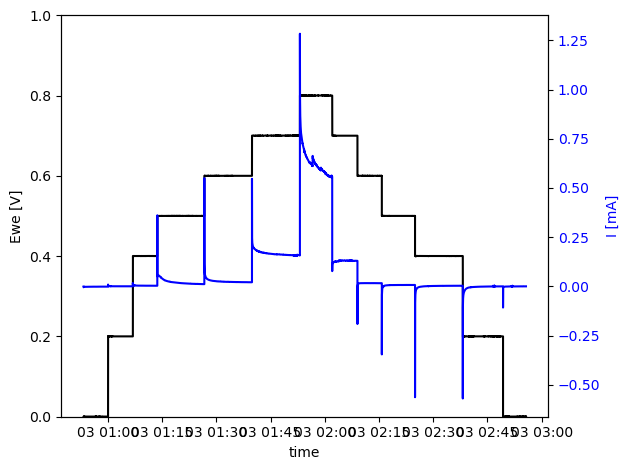

In [5]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.set_xlabel('time')
ax1.set_ylabel('Ewe [V]', color='k')
ax1.plot(df['Ewe/V'], color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.set_ylim(0,1)

ax2.set_ylabel('I [mA]', color='b')
ax2.plot(df['<I>/mA'], color='b')
ax2.tick_params(axis='y', labelcolor='b')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

In [6]:
df.to_csv(os.path.join(output_dir,fname+'.csv'), sep = ',')